In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [53]:
df = pd.read_excel("data/CleanSecurityData.xlsx")

df["Date"] = pd.to_datetime(df["date"])
df = df.sort_values(["cusip", "Date"])

df["DTS"] = df["spread"] * df["duration"]



In [55]:
df2 = df[(df["spread"] > df["spread"].quantile(0.01)) &
        (df["spread"] < df["spread"].quantile(0.99))]

IQR = df['spread'].describe()['75%'] - df['spread'].describe()['25%']
L = df['spread'].describe()['25%'] - 1.5 * IQR
U = df['spread'].describe()['75%'] + 1.5 * IQR

df3 = df[(df['spread'] > L) & (df['spread'] < U)]

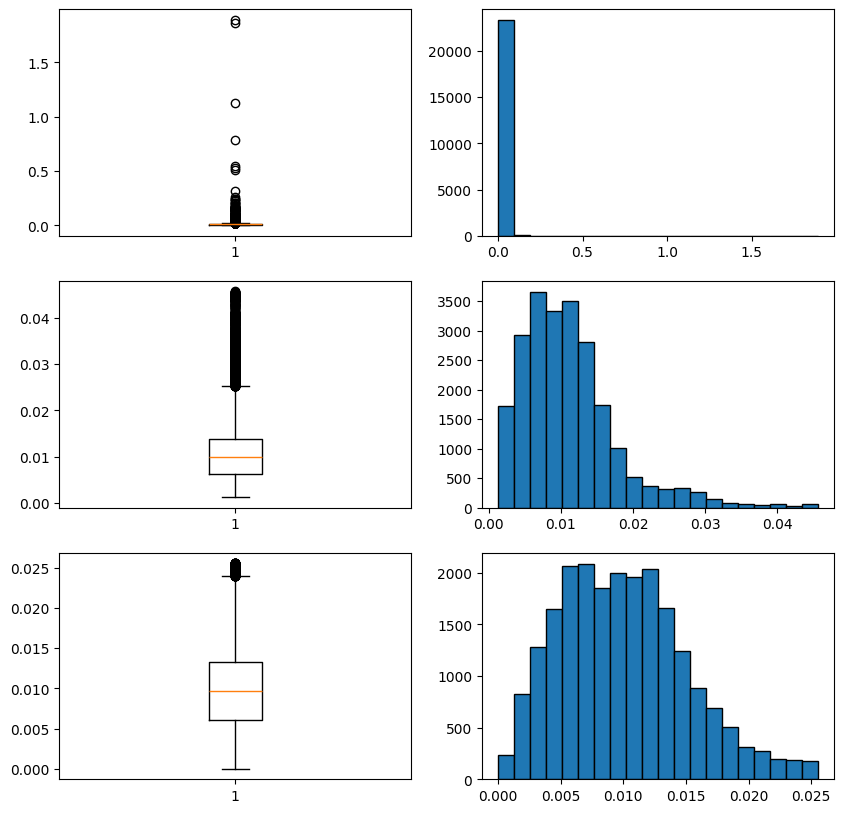

In [56]:
#df = df[df["spread"] != 0]
#df = df[(df["spread"] > df["spread"].quantile(0.01)) &
#        (df["spread"] < df["spread"].quantile(0.99))]
#df = df[df["asset_type"] == "Credit"]


fig, axes = plt.subplots(3,2,figsize=(10, 10))
axes[0,0].boxplot(df['spread'])
axes[0,1].hist(df['spread'], bins = 20, edgecolor = 'black')
axes[1,0].boxplot(df2['spread'])
axes[1,1].hist(df2['spread'], bins = 20, edgecolor = 'black')
axes[2,0].boxplot(df3['spread'])
axes[2,1].hist(df3['spread'], bins = 20, edgecolor = 'black')
plt.show()


In [57]:

df["abs_spread_chg"] = df.groupby("cusip")["spread"].diff()
df["pct_spread_chg"] = df["abs_spread_chg"] / df["spread"]
df = df.dropna()

In [58]:
df["abs_vol"] = df.groupby("cusip")["abs_spread_chg"].rolling(36).std().reset_index(0, drop=True)
df["pct_vol"] = df.groupby("cusip")["pct_spread_chg"].rolling(36).std().reset_index(0, drop=True)
df = df.dropna()

df["excess_return_vol"] = df["DTS"] * df["pct_vol"]

b1 = df["spread"].quantile(0.33)
b2 = df["spread"].quantile(0.66)

df["bucket"] = np.where(df["spread"] < b1, "0",
                        np.where(df["spread"] < b2, "1", "2"))

df = df[df["spread"] >= 0.002]  


In [59]:
grouped = df.groupby(["Date","bucket"]).agg(
    abs_vol_mean=("abs_vol","mean"),
    count=("cusip","count"),
    DTS_mean=("DTS","mean"),
    excess_vol_mean=("excess_return_vol","mean")
).reset_index()

b0 = grouped[(grouped["bucket"] == "0") & (grouped["count"] > 5)]
b1 = grouped[(grouped["bucket"] == "1") & (grouped["count"] > 5)]
b2 = grouped[(grouped["bucket"] == "2") & (grouped["count"] > 5)]

combined = pd.concat([b0,b1,b2])

In [60]:
X = sm.add_constant(combined["DTS_mean"])
y = combined["excess_vol_mean"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        excess_vol_mean   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     1166.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):          1.80e-156
Time:                        19:58:38   Log-Likelihood:                 3265.3
No. Observations:                 774   AIC:                            -6527.
Df Residuals:                     772   BIC:                            -6517.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      4.822      0.0

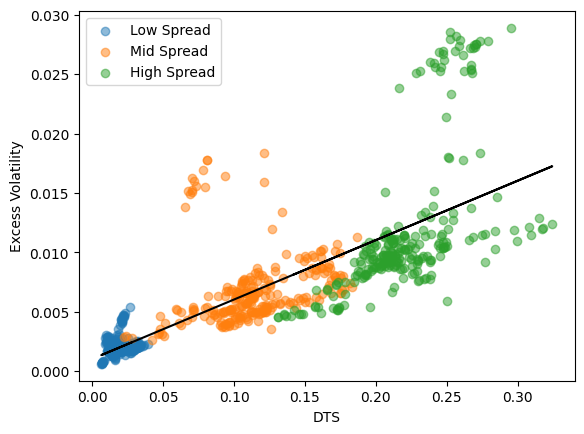

In [61]:
plt.scatter(b0["DTS_mean"], b0["excess_vol_mean"], alpha=0.5, label="Low Spread")
plt.scatter(b1["DTS_mean"], b1["excess_vol_mean"], alpha=0.5, label="Mid Spread")
plt.scatter(b2["DTS_mean"], b2["excess_vol_mean"], alpha=0.5, label="High Spread")

line_x = combined["DTS_mean"]
plt.plot(line_x, model.predict(sm.add_constant(line_x)), color="black")

plt.xlabel("DTS")
plt.ylabel("Excess Volatility")
plt.legend()
plt.show()

In [62]:
X = sm.add_constant(combined["DTS_mean"])
y = combined["abs_vol_mean"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           abs_vol_mean   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     56.96
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           1.26e-13
Time:                        19:58:38   Log-Likelihood:                 4387.6
No. Observations:                 774   AIC:                            -8771.
Df Residuals:                     772   BIC:                            -8762.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008   5.02e-05     15.922      0.0

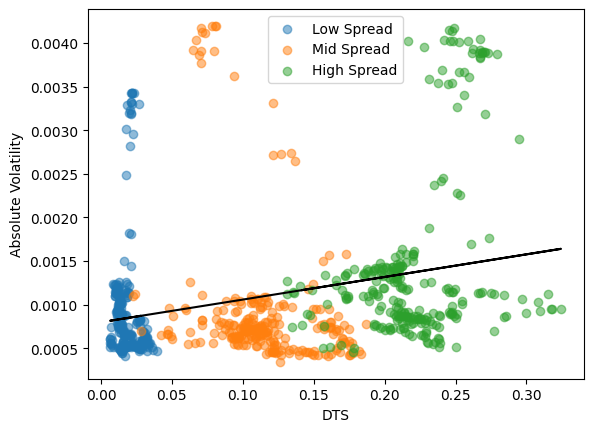

In [63]:
plt.scatter(b0["DTS_mean"], b0["abs_vol_mean"], alpha=0.5, label="Low Spread")
plt.scatter(b1["DTS_mean"], b1["abs_vol_mean"], alpha=0.5, label="Mid Spread")
plt.scatter(b2["DTS_mean"], b2["abs_vol_mean"], alpha=0.5, label="High Spread")

line_x = combined["DTS_mean"]
plt.plot(line_x, model.predict(sm.add_constant(line_x)), color="black")

plt.xlabel("DTS")
plt.ylabel("Absolute Volatility")
plt.legend()
plt.show()

In [64]:
mask = ~combined["Date"].between("2020-01-01","2021-01-01")
filtered = combined[mask]

X2 = sm.add_constant(filtered["DTS_mean"])
y2 = filtered["excess_vol_mean"]
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        excess_vol_mean   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     5678.
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:58:38   Log-Likelihood:                 3591.5
No. Observations:                 665   AIC:                            -7179.
Df Residuals:                     663   BIC:                            -7170.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014   7.11e-05     19.270      0.0

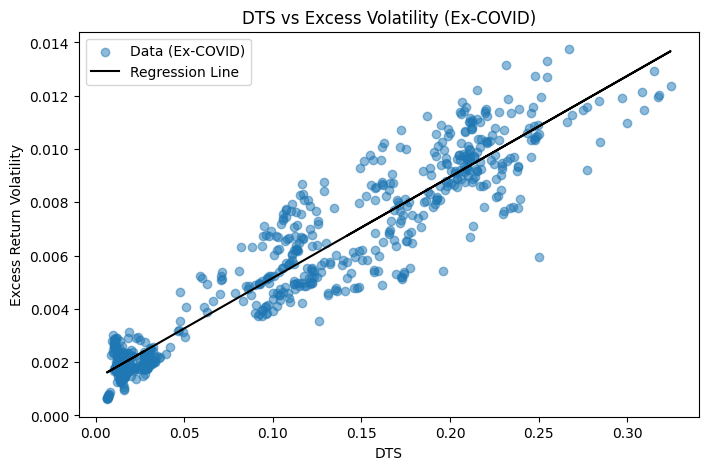

In [65]:
mask = ~combined["Date"].between("2020-01-01", "2021-01-01")
filtered = combined[mask]

plt.figure(figsize=(8,5))

plt.scatter(filtered["DTS_mean"], filtered["excess_vol_mean"],
            alpha=0.5, label="Data (Ex-COVID)")

plt.plot(filtered["DTS_mean"],
         model2.predict(sm.add_constant(filtered["DTS_mean"])),
         color="black", label="Regression Line")

plt.xlabel("DTS")
plt.ylabel("Excess Return Volatility")
plt.title("DTS vs Excess Volatility (Ex-COVID)")
plt.legend()
plt.show()

In [66]:
mask = ~combined["Date"].between("2020-01-01","2021-01-01")
filtered = combined[mask]

X2 = sm.add_constant(filtered["DTS_mean"])
y2 = filtered["abs_vol_mean"]
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           abs_vol_mean   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     85.22
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           3.54e-19
Time:                        19:58:39   Log-Likelihood:                 4514.6
No. Observations:                 665   AIC:                            -9025.
Df Residuals:                     663   BIC:                            -9016.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007   1.77e-05     39.601      0.0

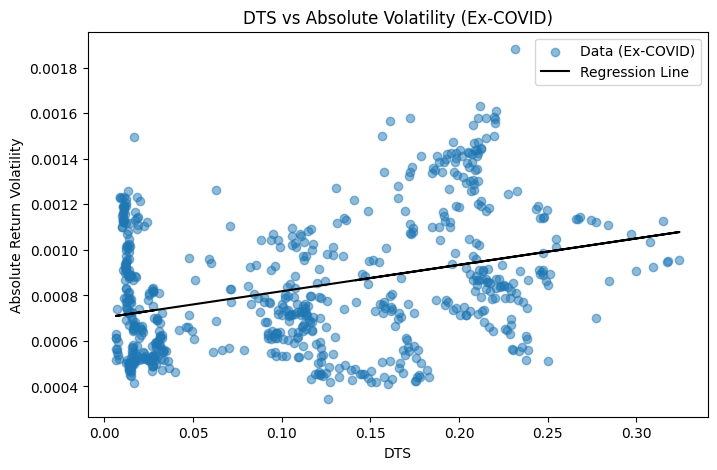

In [67]:
mask = ~combined["Date"].between("2020-01-01", "2021-01-01")
filtered = combined[mask]

plt.figure(figsize=(8,5))

plt.scatter(filtered["DTS_mean"], filtered["abs_vol_mean"],
            alpha=0.5, label="Data (Ex-COVID)")

plt.plot(filtered["DTS_mean"],
         model2.predict(sm.add_constant(filtered["DTS_mean"])),
         color="black", label="Regression Line")

plt.xlabel("DTS")
plt.ylabel("Absolute Return Volatility")
plt.title("DTS vs Absolute Volatility (Ex-COVID)")
plt.legend()
plt.show()